## Christian Jay P. Magsigay


## Exercise 5.12 - Racetrack (Reinforcement Learning: An Introduction by Sutton and Barto)

Consider driving a race car around a turn like those shown in Figure 5.5. You want to go as fast
as possible, but not so fast as to run off the track. In our simplified racetrack, the car is at
one of a discrete set of grid positions, the cells in the diagram. The velocity is also discrete,
a number of grid cells moved horizontally and vertically per time step.
 
The actions are increments to the velocity components. Each may be changed by +1, 0 or -1 in
each step, for a total of nine (3 x 3) actions. Both velocity components are restricted to
be non-negative and less than 5, and they cannot both be zero except at the starting line.
 
Each episode begins in one of the randomly selected start states with both velocity components zero
and ends when the car crosses the finish line. The rewards are -1 for each step until the car
crosses the finish line. If the car hits the track boundary, it is moved back to a random position
on the starting line, both velocity components are reduced to zero, and the episode continues.

Before updating the car’s location at each time step, check to see if the projected path of the
car intersects the track boundary. If it intersects the finish line, the episode ends; if it
intersects anywhere else, the car is considered to have hit the track boundary and is sent back
to the starting line. To make the task more challenging, with probability 0.1 at each time step
the velocity increments are both zero, independently of the intended increments.
 
Apply a Monte Carlo control method to this task to compute the optimal policy from each starting
state. Exhibit several trajectories following the optimal policy (but turn the noise off for these
trajectories).

In [ ]:
! pip3 -q install gym

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import gym
import racetrack
from mc import sample_episode, monte_carlo_control_eps_soft

### Monte-Carlo Control for Epsilon Soft Policies

The Monte Carlo control algorithm uses a constant step size $\alpha$ instead of averaging like in the pseudo-code in Chapter 5.4, allowing it to forget poor early episodes in a non-stationary setting where the policy keeps changing. The older really bad episodes would never happen under the current iteration of the policy. Therefore, forgetting the earlier experiences is beneficial for more accurate estimation of the current $Q$ value.

It also uses optimistic initial $Q$ values to encourage exploration, so unexplored actions look better than tried (negative-return) ones. This reduces the need for a high exploration rate $\epsilon$, though a fixed nonzero $\epsilon$ prevents full convergence—so it’s better to gradually decrease $\epsilon$ over time.

In [3]:
matplotlib.rcParams['figure.figsize'] = [10, 10]  # Set default figure size
def plot_results(env, q, policy, road):

    # VALUE FUNCTION VISUALIZATION

    # Take the maximum over actions → V(s) = max_a Q(s,a)
    v = np.max(q, axis=1).reshape(env.observation_space.nvec)

    # Average over velocity dimensions → collapse (vx, vy)
    # Result: value per (position_x, position_y)
    v_pos = np.mean(v, axis=(2, 3))        

    # Identify states that were never visited:
    # since Q initialized to 1, untouched states still have value 1
    unvisited_filter = np.where(v_pos == 1.0)
    
    finite_vals = v_pos[np.isfinite(v_pos)]
    if len(finite_vals) > 0:
        vmin, vmax = np.nanpercentile(finite_vals, [2, 98])
        v_pos = np.clip(v_pos, vmin, vmax)

    # Mask unvisited states so they don't distort the plot
    v_pos[unvisited_filter] = np.nan
    
    # Plot value function over positions
    plt.figure()
    plt.title("Value Function Averaged over Speeds", fontsize=20)
    plt.xlabel("X", fontsize=14)
    plt.ylabel("Y", fontsize=14)

    # Heatmap
    plt.imshow(v_pos.T, origin='lower', cmap='plasma')
    plt.colorbar()

    # Save figure
    plt.savefig(f"media/{road} Value Function Averaged over Speeds.png")
    

    # POLICY (ACTION) VISUALIZATION

    # Get greedy action index per state
    a_star_ridxs = np.argmax(policy, axis=1).reshape(env.observation_space.nvec)

    # Convert flattened action index → actual acceleration (ax, ay)
    # Then shift by max_accel to get values in {-1, 0, 1}
    a_stars = np.array(np.unravel_index(a_star_ridxs, env.action_space.nvec)) - env.max_accel

    # Average actions over velocity dimensions → one action per position
    a_stars_mean = np.mean(a_stars, axis=(-1, -2))

    # Normalize for visualization (center arrows around zero)
    a_stars_norm = (a_stars_mean.T - np.mean(a_stars_mean, axis=(1, 2))).T

    # Remove arrows in unvisited states (avoid misleading directions)
    a_stars_norm[:, unvisited_filter[0], unvisited_filter[1]] = 0
    

    # OVERLAY POLICY ON TRACK

    env.reset()
    axis = env.render()  # draw racetrack background

    xs = np.arange(env.observation_space.nvec[0])
    ys = np.arange(env.observation_space.nvec[1])

    # Extract x and y components of averaged actions
    a_star_x, a_star_y = a_stars_norm[0], a_stars_norm[1]

    # Plot arrows showing preferred direction at each position
    axis.quiver(xs, ys, a_star_x.T, a_star_y.T)
    
    plt.title("Action Averaged Over Speeds", fontsize=20)
    plt.xlabel("X", fontsize=14)
    plt.ylabel("Y", fontsize=14)

    # Save policy visualization
    plt.savefig(f"media/{road} Action Averaged Over Speeds.png")

## Solution to Track 1

In [12]:
import time

env = gym.make('Racetrack-v0', track='figure05-05-right')

n_ep=1_000_000

start = time.time()
q, policy, returns_log = monte_carlo_control_eps_soft(env, n_ep, eps=0.05, alpha=0.10)
end = time.time()

print("Training time (seconds):", end - start, f"s after {n_ep} episodes")

Episode 0/1000000: return=-131.0
Episode 10000/1000000: return=-16.0
Episode 20000/1000000: return=-27.0
Episode 30000/1000000: return=-15.0
Episode 40000/1000000: return=-21.0
Episode 50000/1000000: return=-16.0
Episode 60000/1000000: return=-17.0
Episode 70000/1000000: return=-10.0
Episode 80000/1000000: return=-10.0
Episode 90000/1000000: return=-12.0
Episode 100000/1000000: return=-12.0
Episode 110000/1000000: return=-21.0
Episode 120000/1000000: return=-15.0
Episode 130000/1000000: return=-16.0
Episode 140000/1000000: return=-13.0
Episode 150000/1000000: return=-15.0
Episode 160000/1000000: return=-10.0
Episode 170000/1000000: return=-9.0
Episode 180000/1000000: return=-22.0
Episode 190000/1000000: return=-9.0
Episode 200000/1000000: return=-10.0
Episode 210000/1000000: return=-9.0
Episode 220000/1000000: return=-8.0
Episode 230000/1000000: return=-13.0
Episode 240000/1000000: return=-12.0
Episode 250000/1000000: return=-22.0
Episode 260000/1000000: return=-12.0
Episode 270000/100

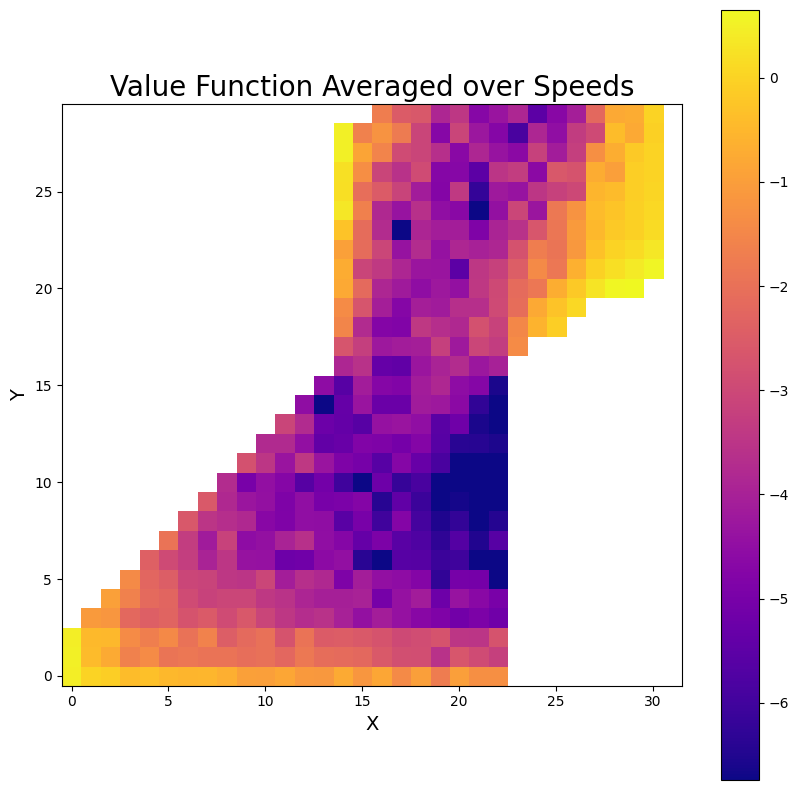

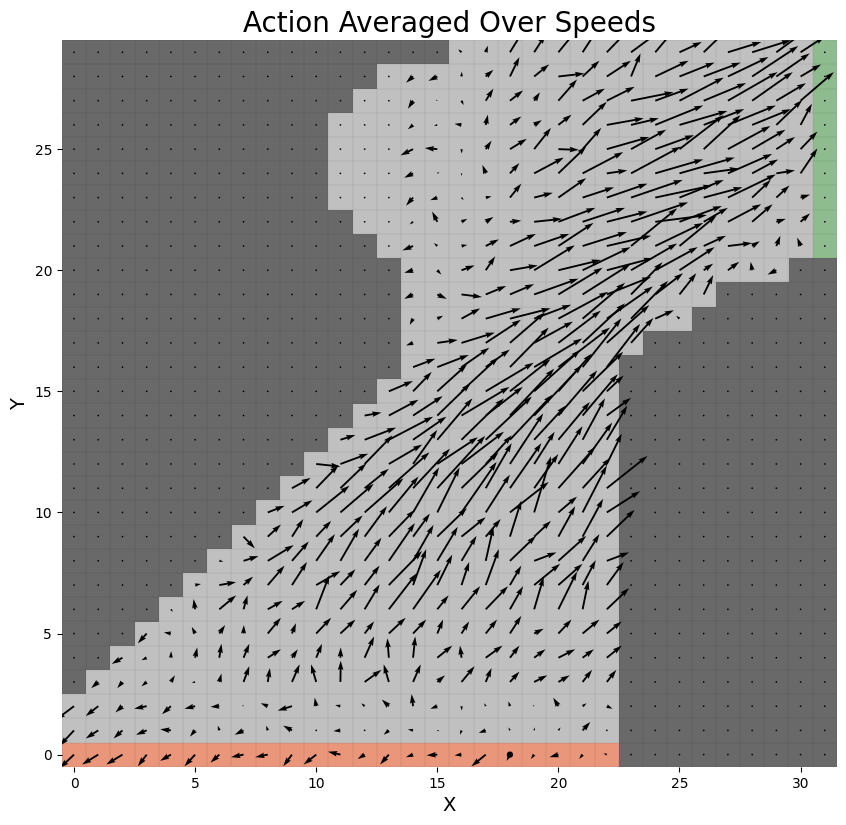

In [13]:
plot_results(env, q, policy, 1)

## Sample Trajectories

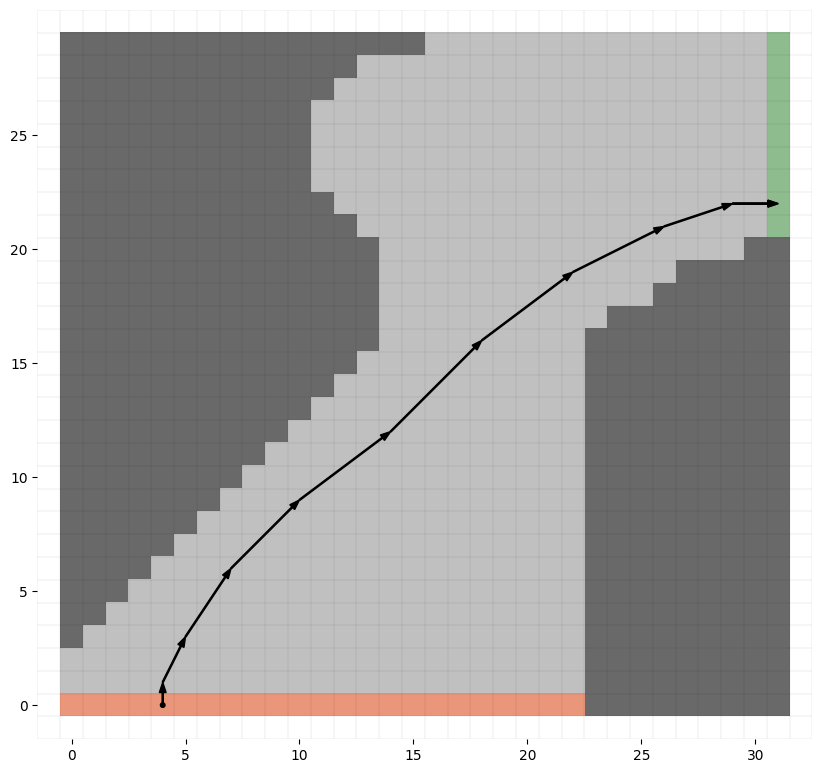

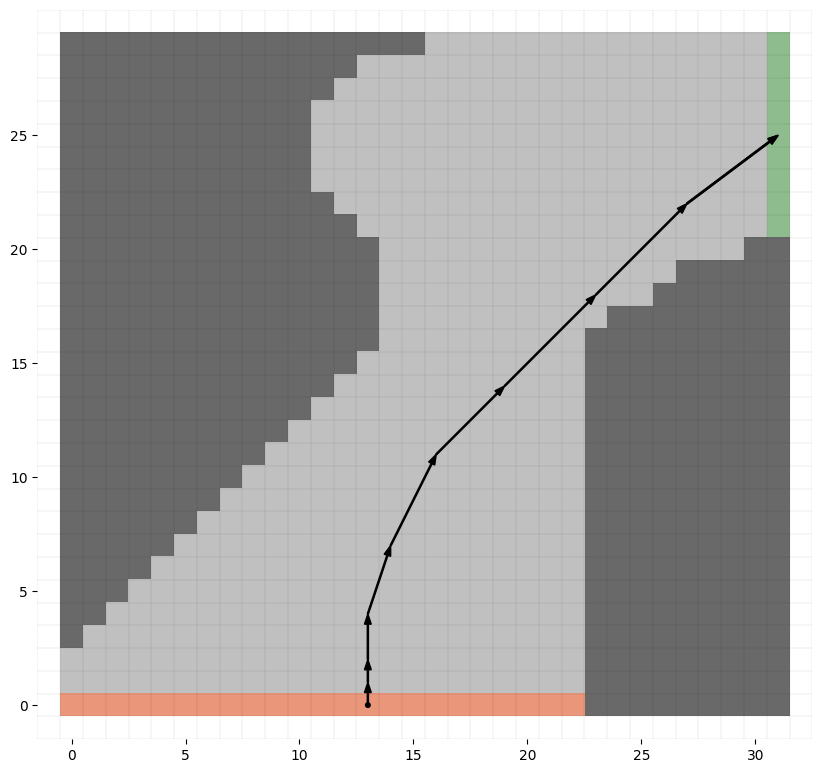

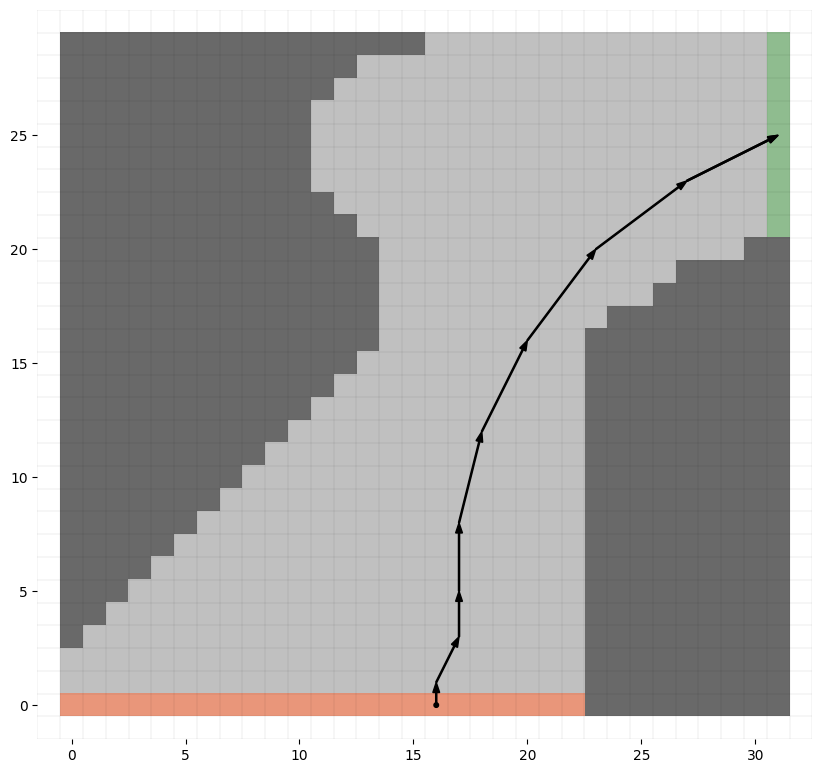

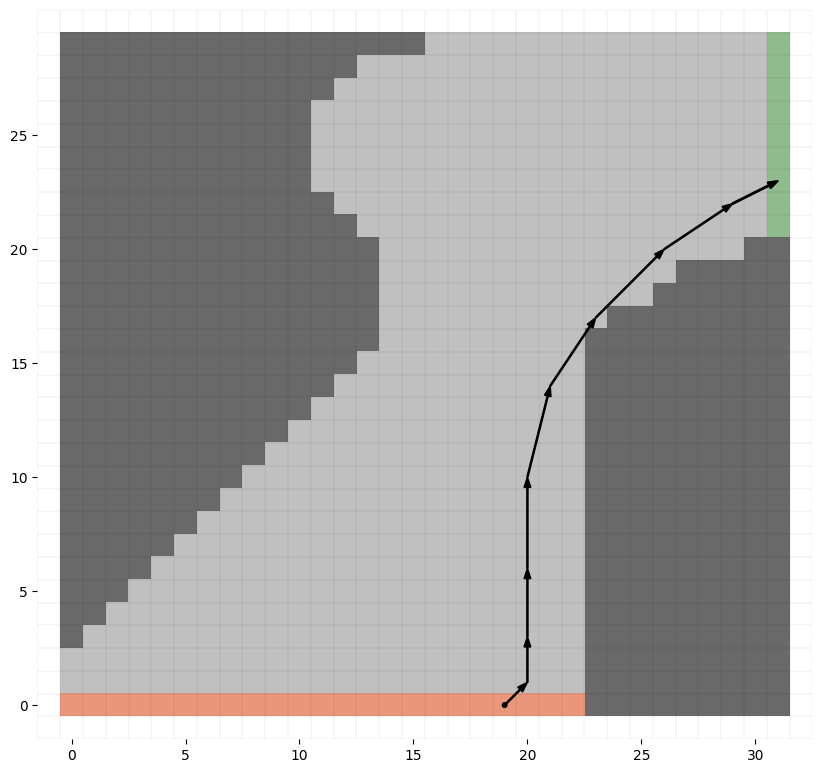

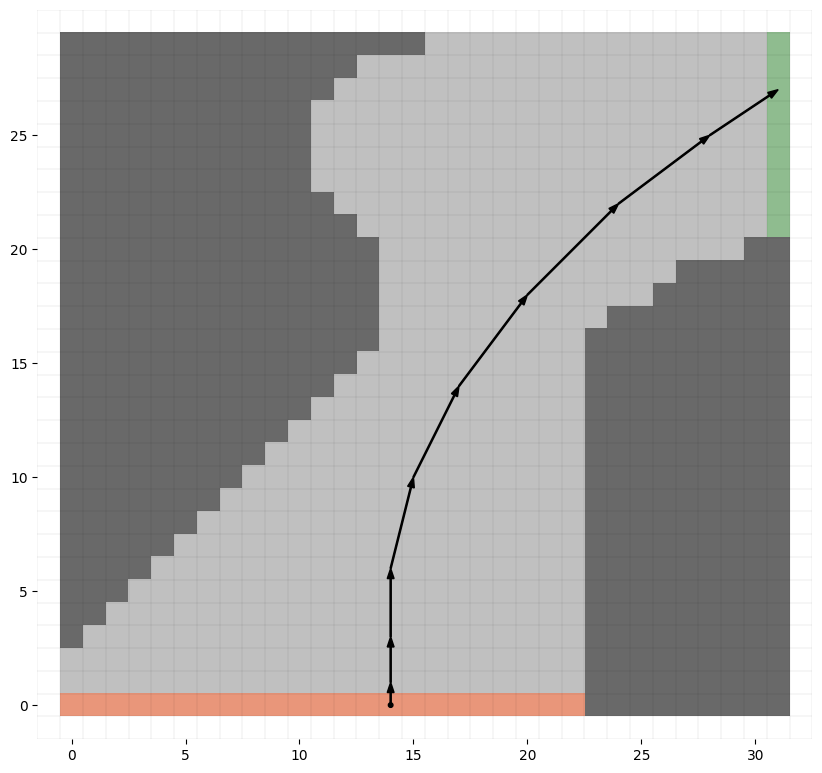

In [14]:
env0 = gym.make('Racetrack-v0', track='figure05-05-right', noisy=False)
for n in range(5):
    sample_episode(env0, policy, render=True)
    plt.savefig(f"media/1 plot_{n}.png")

## Learning Curve

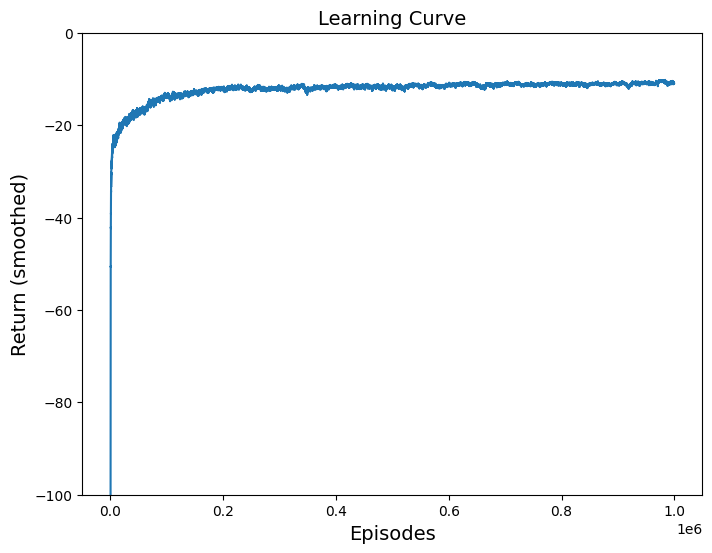

In [15]:
# Smoothening
def moving_average(x, w=500):
    return np.convolve(x, np.ones(w)/w, mode='valid')
smoothed=moving_average(returns_log)

plt.figure(figsize=(8,6))
plt.plot(smoothed)
plt.xlabel("Episodes", fontsize=14)
plt.ylabel("Return (smoothed)", fontsize=14)
plt.title("Learning Curve", fontsize=14)
plt.ylim(-100,0)
plt.savefig(f"media/1 learning_curve.png")
plt.show()

## Solution to Track 2

In [16]:
env = gym.make('Racetrack-v0', track='figure05-05-left')

n_ep=1_000_000

start = time.time()
q, policy,returns_log = monte_carlo_control_eps_soft(env, n_ep, eps=0.05, alpha=0.10)
end = time.time()

print("Training time (seconds):", end - start, f"s after {n_ep} episodes")

Episode 0/1000000: return=-240.0
Episode 10000/1000000: return=-19.0
Episode 20000/1000000: return=-39.0
Episode 30000/1000000: return=-26.0
Episode 40000/1000000: return=-18.0
Episode 50000/1000000: return=-59.0
Episode 60000/1000000: return=-44.0
Episode 70000/1000000: return=-68.0
Episode 80000/1000000: return=-15.0
Episode 90000/1000000: return=-16.0
Episode 100000/1000000: return=-132.0
Episode 110000/1000000: return=-32.0
Episode 120000/1000000: return=-20.0
Episode 130000/1000000: return=-72.0
Episode 140000/1000000: return=-34.0
Episode 150000/1000000: return=-18.0
Episode 160000/1000000: return=-14.0
Episode 170000/1000000: return=-28.0
Episode 180000/1000000: return=-42.0
Episode 190000/1000000: return=-21.0
Episode 200000/1000000: return=-46.0
Episode 210000/1000000: return=-13.0
Episode 220000/1000000: return=-18.0
Episode 230000/1000000: return=-15.0
Episode 240000/1000000: return=-12.0
Episode 250000/1000000: return=-43.0
Episode 260000/1000000: return=-11.0
Episode 27000

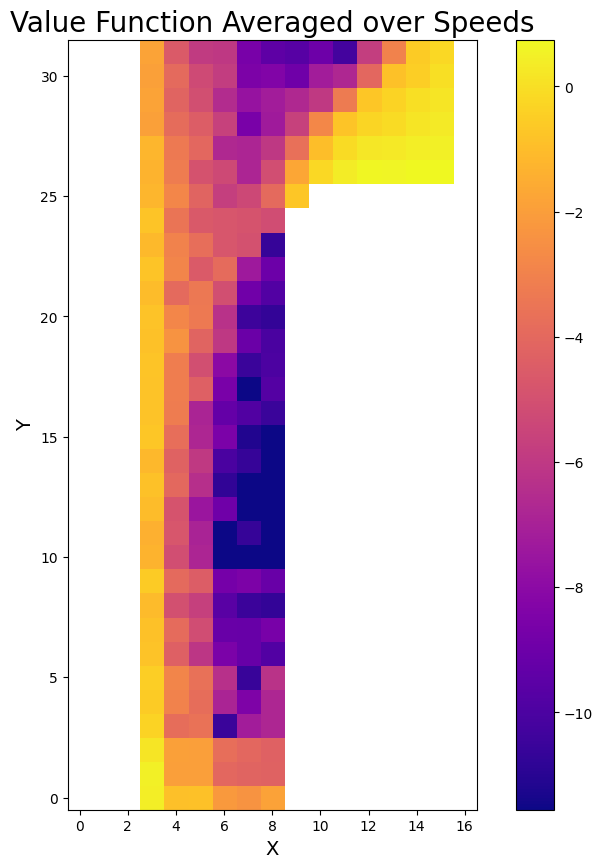

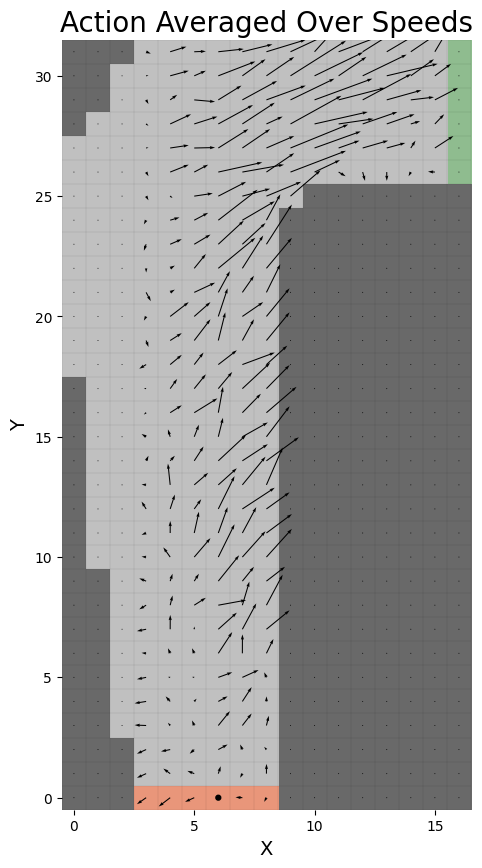

In [17]:
plot_results(env, q, policy, 2)

## Sample Trajectories

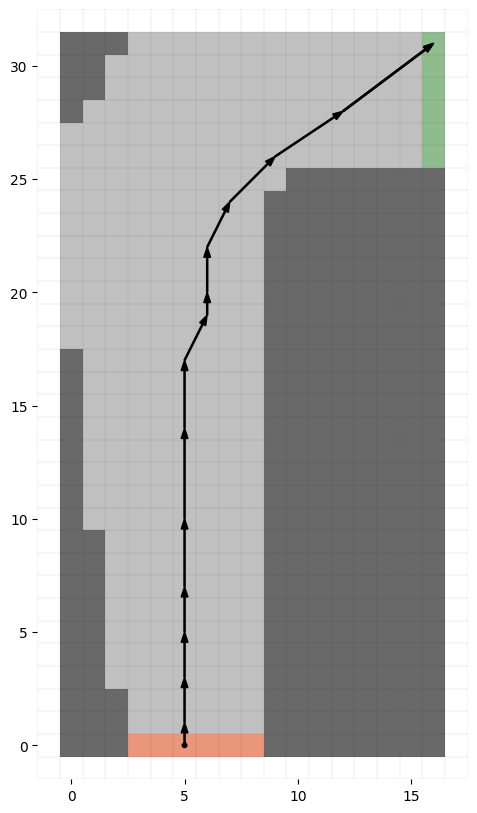

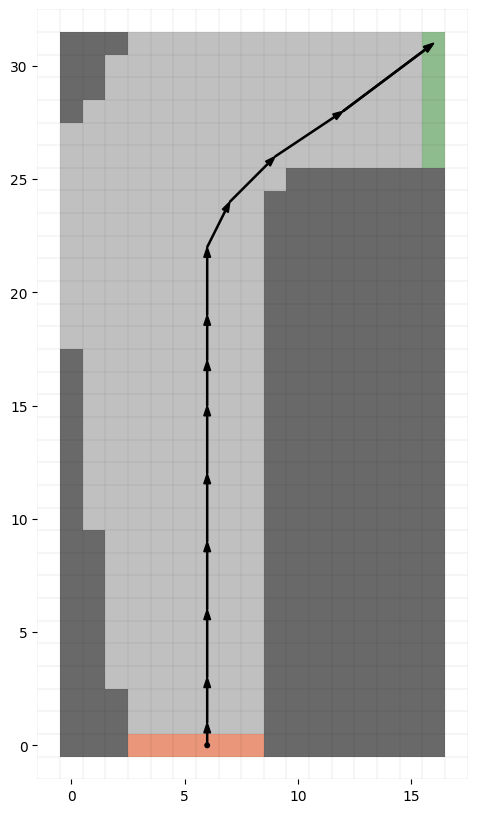

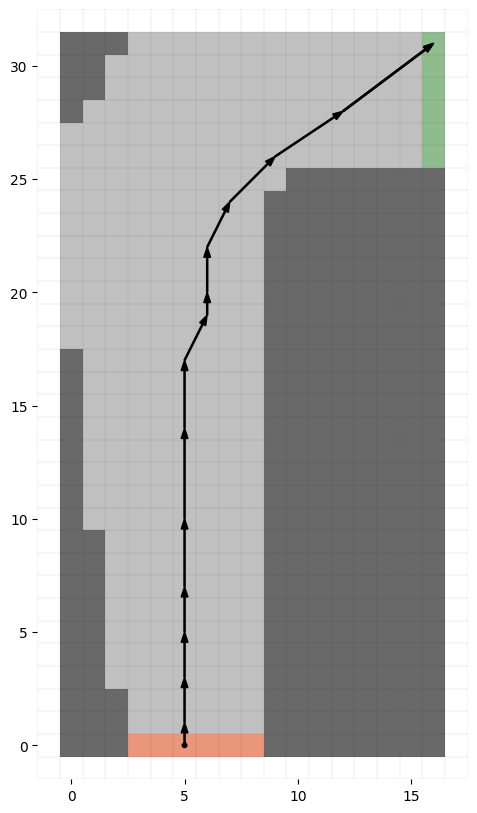

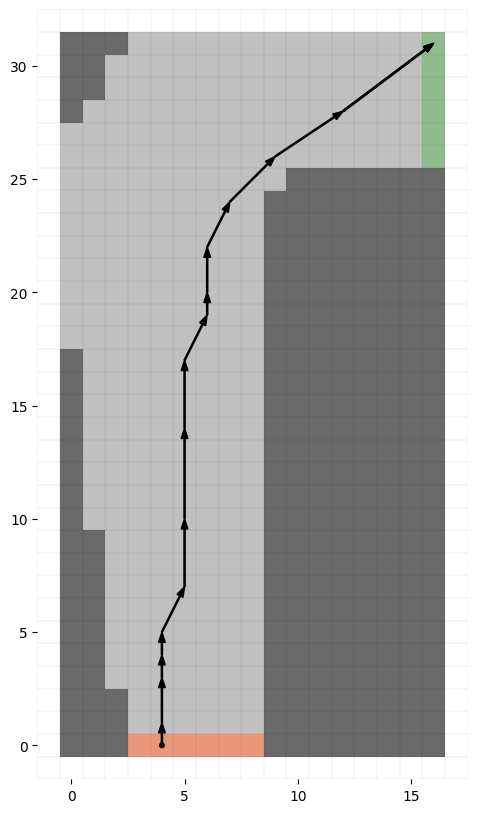

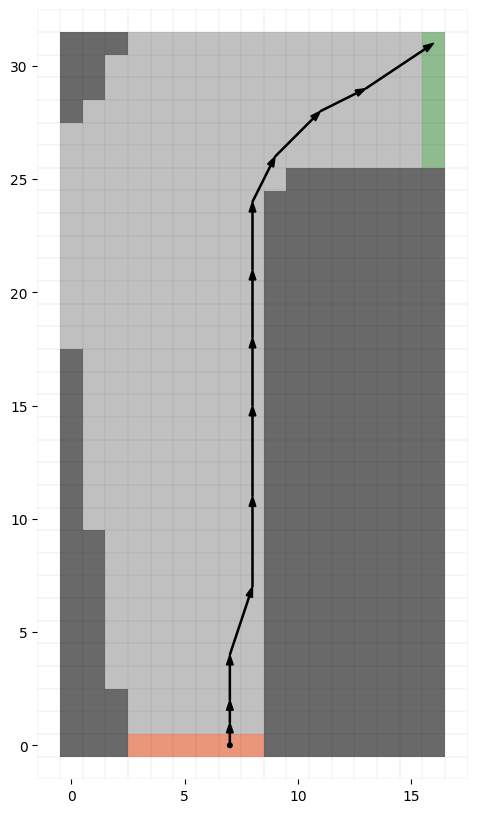

In [20]:
env = gym.make('Racetrack-v0', track='figure05-05-left', noisy=False)
for n in range(5):
    sample_episode(env, policy, render=True)
    plt.savefig(f"media/2 plot_{n}.png")

## Learning Curve

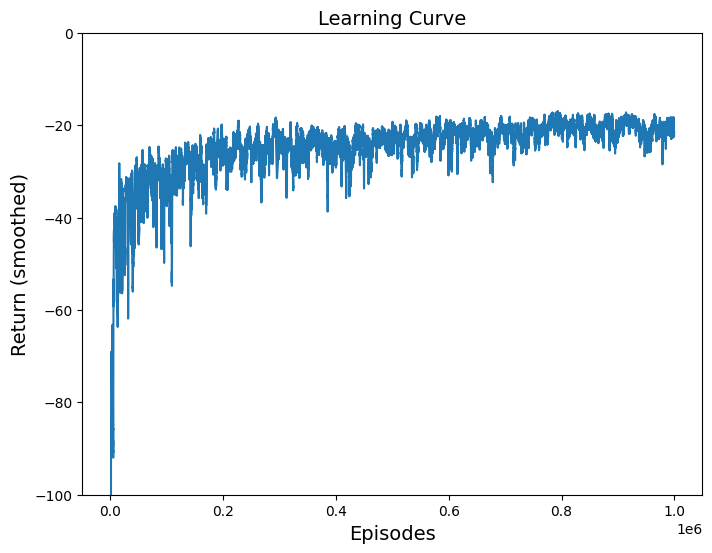

In [19]:
smoothed=moving_average(returns_log)

plt.figure(figsize=(8,6))
plt.plot(smoothed)
plt.xlabel("Episodes", fontsize=14)
plt.ylabel("Return (smoothed)", fontsize=14)
plt.title("Learning Curve", fontsize=14)
plt.ylim(-100,0)
plt.savefig(f"media/2 learning_curve.png")
plt.show()